# Assignment 1: Building Neural Networks for Image Classification

## Overview
Welcome back to Assignment 1! In this assignment, you'll dive into the fascinating realm of deep learning by building and training neural networks for image classification and object detection tasks using the PyTorch framework. You'll work with two popular datasets: MNIST for image classification and CIFAR-100 for object detection. Throughout the assignment, you'll also fine-tune your models to achieve optimal results.

## Part 3: Achieve Best Accuracy
In the final section of the assignment, you'll take your models to the next level by modifying the model and achieving benchmark performance. You'll experiment with different architectures, hyperparameters, learning rates, and optimization techniques to achieve the best possible accuracy for object classification (CIFAR-100). Your journey will involve analyzing the impact of these changes on the models' accuracy and convergence. Feel free to write your own modules, and make changes to starter code to achieve highest possible accuracy. Results are expected to be submitted in the same format as previous sections however.

Note: You can implement one of the AlexNet, ResNet18, ResNet50, or other architectures discussed in class. However, No transfer learning or pretrained models allowed.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cuda':
    print(f" {torch.cuda.get_device_name(0)}")
# Specify font family to avoid font warnings on Colab
plt.rcParams['font.family'] = 'DejaVu Sans'

 NVIDIA A100 80GB PCIe


In [3]:
from data import get_dataloaders
import neural_network
import trainer
import visualize

In [4]:
# Hyperparameters
# TODO: Experiment with different hyperparameters
batch_size = 32
learning_rate = 0.1
epochs = 20

In [5]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
 # TODO: note that you want to keep
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
  # TODO

trainloader, testloader = get_dataloaders(
    dataset_name="cifar100", 
    batch_size=batch_size, 
    train_transforms=transform_train, 
    test_transforms=transform_test
)

Files already downloaded and verified
Files already downloaded and verified


In [6]:
# TODO: Initialize the model, loss function, and optimizer
model = neural_network.BetterModel(num_classes=100, in_channels=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [7]:
# TODO: Training loop
train_losses, test_losses = trainer.train(
    model, optimizer, criterion, trainloader, testloader, epochs, device, scheduler
)

Epoch 1/20 - Train Loss: 4.09544182403379
Epoch 1/20 - Test Loss: 3.757008360597653
Epoch 1/20 - Test Accuracy: 11.06%
Epoch 2/20 - Train Loss: 3.5395569448965296
Epoch 2/20 - Test Loss: 3.273009865428693
Epoch 2/20 - Test Accuracy: 19.89%
Epoch 3/20 - Train Loss: 3.2116631015477393
Epoch 3/20 - Test Loss: 2.892441399942953
Epoch 3/20 - Test Accuracy: 26.76%
Epoch 4/20 - Train Loss: 2.867243809114262
Epoch 4/20 - Test Loss: 2.9785585494848865
Epoch 4/20 - Test Accuracy: 26.88%
Epoch 5/20 - Train Loss: 2.5687647036688492
Epoch 5/20 - Test Loss: 2.6377587200353703
Epoch 5/20 - Test Accuracy: 32.52%
Epoch 6/20 - Train Loss: 2.3708482997507447
Epoch 6/20 - Test Loss: 2.3042753066498634
Epoch 6/20 - Test Accuracy: 39.10%
Epoch 7/20 - Train Loss: 2.225989049547236
Epoch 7/20 - Test Loss: 2.8640701328984464
Epoch 7/20 - Test Accuracy: 31.37%
Epoch 8/20 - Train Loss: 2.1098841784172766
Epoch 8/20 - Test Loss: 2.392100340261246
Epoch 8/20 - Test Accuracy: 39.05%
Epoch 9/20 - Train Loss: 1.99633

# Visualize Final Results: Best Model - CIFAR 100

In [8]:
# Evaluate the models
accuracy = trainer.evaluate_accuracy(model, testloader, device)
train_acc = trainer.evaluate_accuracy(model, trainloader, device)

print("C3_scheduler_cosine Model Test Accuracy:", accuracy)
print("C3_scheduler_cosine Train Accuracy:", train_acc)

C3_scheduler_cosine Model Test Accuracy: 71.53
C3_scheduler_cosine Train Accuracy: 87.102


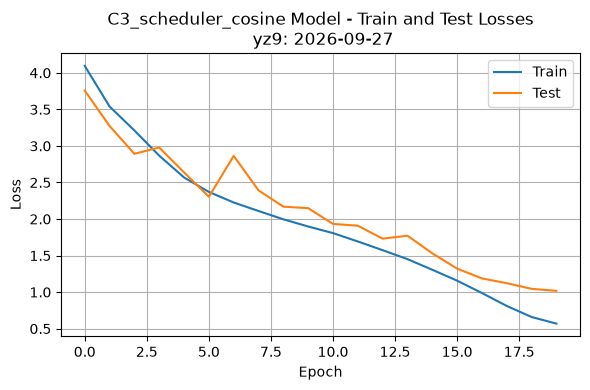

In [9]:
# Plot train and test losses
visualize.visualize_loss(train_losses, test_losses, "C3_scheduler_cosine Model")

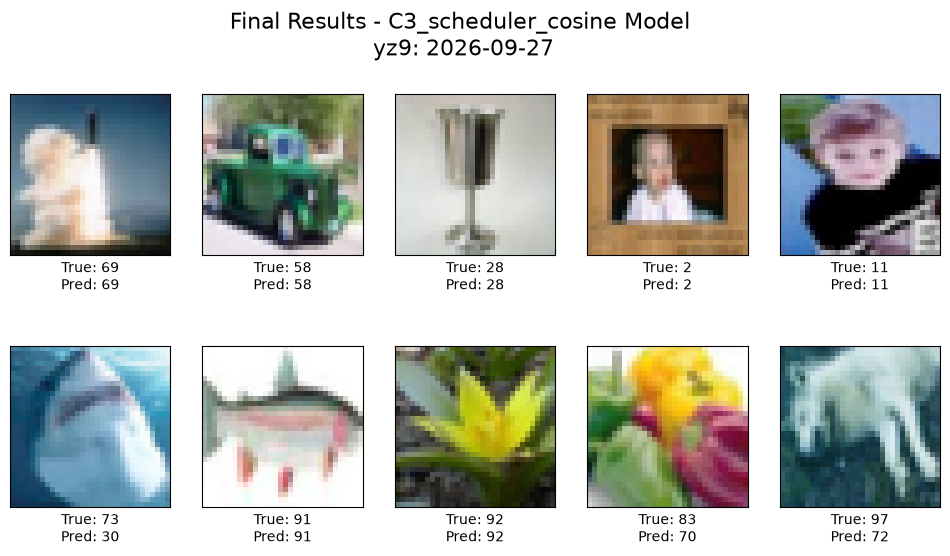

In [10]:
# Visualize the final results
visualize.visualize_images(model, testloader.dataset, device, "C3_scheduler_cosine Model")